In [2]:
from langgraph.graph import StateGraph ,START ,END
from tavily import TavilyClient
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.messages import BaseMessage , HumanMessage
from langgraph.prebuilt import ToolNode
from langchain_openai import ChatOpenAI 
from dotenv import load_dotenv

In [3]:
load_dotenv()

True

In [24]:
class state(TypedDict):
  messages:Annotated[list[BaseMessage], add_messages]

In [7]:
search_tool= TavilySearchResults(max_results=2)
tools=[search_tool]
model=ChatOpenAI(model="gpt-4o-mini").bind_tools(tools)

In [ ]:
def call_model(state : state):
   message=state['messages']
   response=model.invoke(message)
   return{"messages": [response]}

def should_continue(state : state):
   last_message = state["messages"][-1]
   if last_message.tool_calls:
        return "tools"
   return END

In [ ]:
workflow=StateGraph(state)
workflow.add_node("agent",call_model)
workflow.add_node("tools",ToolNode(tools))
workflow.add_edge(START , "agent")
workflow.add_conditional_edges("agent", should_continue)
workflow.add_edge("tools","agent")
app= workflow.compile()
input_data = {
    "messages": [
        HumanMessage(content="psl schedule when is lahore kalandar next match")
    ]
}

result = app.invoke(input_data)
print(result)


BadRequestError: Error code: 400 - {'error': {'message': "Invalid 'messages': empty array. Expected an array with minimum length 1, but got an empty array instead.", 'type': 'invalid_request_error', 'param': 'messages', 'code': 'empty_array'}}

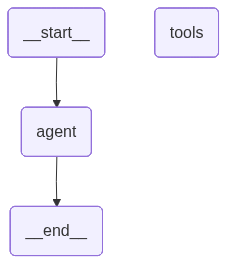

In [19]:
app